# Lab 5: Naïve Bayes and Decision Tree Classification
## Objective
Build Naïve Bayes and Decision Tree classification models and evaluate their performance using appropriate metrics.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Load and Prepare Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')

feature_cols = df.columns[:-1]
X = df[feature_cols]
y = df['Class']
class_names = ['Kama', 'Rosa', 'Canadian']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing:  {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

Training: 168 samples
Testing:  42 samples
Features: 7


---
## Part A: Naïve Bayes Classifier

### 3. Train Gaussian Naïve Bayes

In [3]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

print("Gaussian Naïve Bayes Model Trained")
print("=" * 45)
print(f"Classes: {nb_model.classes_}")
print(f"Class priors: {nb_model.class_prior_}")

Gaussian Naïve Bayes Model Trained
Classes: [1 2 3]
Class priors: [0.33333333 0.33333333 0.33333333]


### 4. Evaluate Naïve Bayes

In [4]:
y_pred_nb = nb_model.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print("Naïve Bayes — Evaluation Metrics")
print("=" * 45)
print(f"Accuracy:  {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall:    {rec_nb:.4f}")
print(f"F1 Score:  {f1_nb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=class_names))

Naïve Bayes — Evaluation Metrics
Accuracy:  0.8810
Precision: 0.8871
Recall:    0.8810
F1 Score:  0.8773

Classification Report:
              precision    recall  f1-score   support

        Kama       0.91      0.71      0.80        14
        Rosa       0.93      0.93      0.93        14
    Canadian       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.89      0.88      0.88        42
weighted avg       0.89      0.88      0.88        42



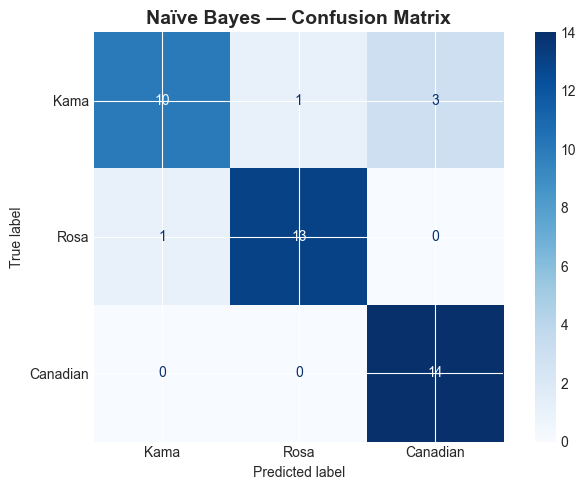

In [5]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Naïve Bayes — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Cross-validation
cv_scores_nb = cross_val_score(nb_model, scaler.transform(X), y, cv=5, scoring='accuracy')
print("Cross-Validation (5-fold):")
print(f"Scores: {cv_scores_nb}")
print(f"Mean Accuracy: {cv_scores_nb.mean():.4f} ± {cv_scores_nb.std():.4f}")

Cross-Validation (5-fold):
Scores: [0.88095238 0.92857143 0.95238095 0.97619048 0.69047619]
Mean Accuracy: 0.8857 ± 0.1026


---
## Part B: Decision Tree Classifier

### 5. Train Decision Tree

In [7]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=5)
dt_model.fit(X_train_scaled, y_train)

print("Decision Tree Classifier")
print("=" * 45)
print(f"Max Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")
print(f"Number of Features: {dt_model.n_features_in_}")

Decision Tree Classifier
Max Depth: 5
Number of Leaves: 12
Number of Features: 7


### 6. Evaluate Decision Tree

In [8]:
y_pred_dt = dt_model.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree — Evaluation Metrics")
print("=" * 45)
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall:    {rec_dt:.4f}")
print(f"F1 Score:  {f1_dt:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=class_names))

Decision Tree — Evaluation Metrics
Accuracy:  0.8810
Precision: 0.8836
Recall:    0.8810
F1 Score:  0.8766

Classification Report:
              precision    recall  f1-score   support

        Kama       0.91      0.71      0.80        14
        Rosa       0.87      0.93      0.90        14
    Canadian       0.88      1.00      0.93        14

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



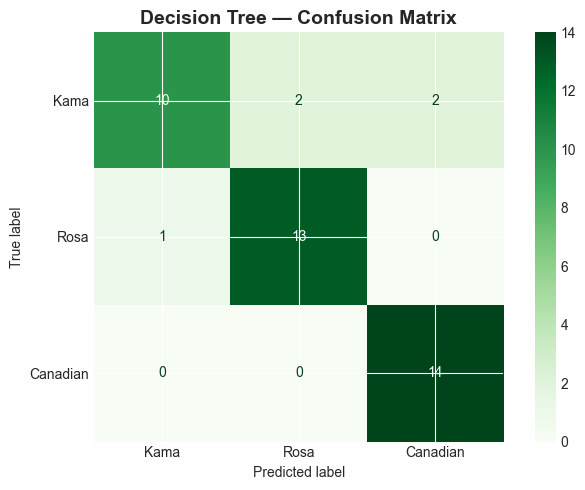

In [9]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=class_names)
disp.plot(cmap='Greens', ax=ax)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

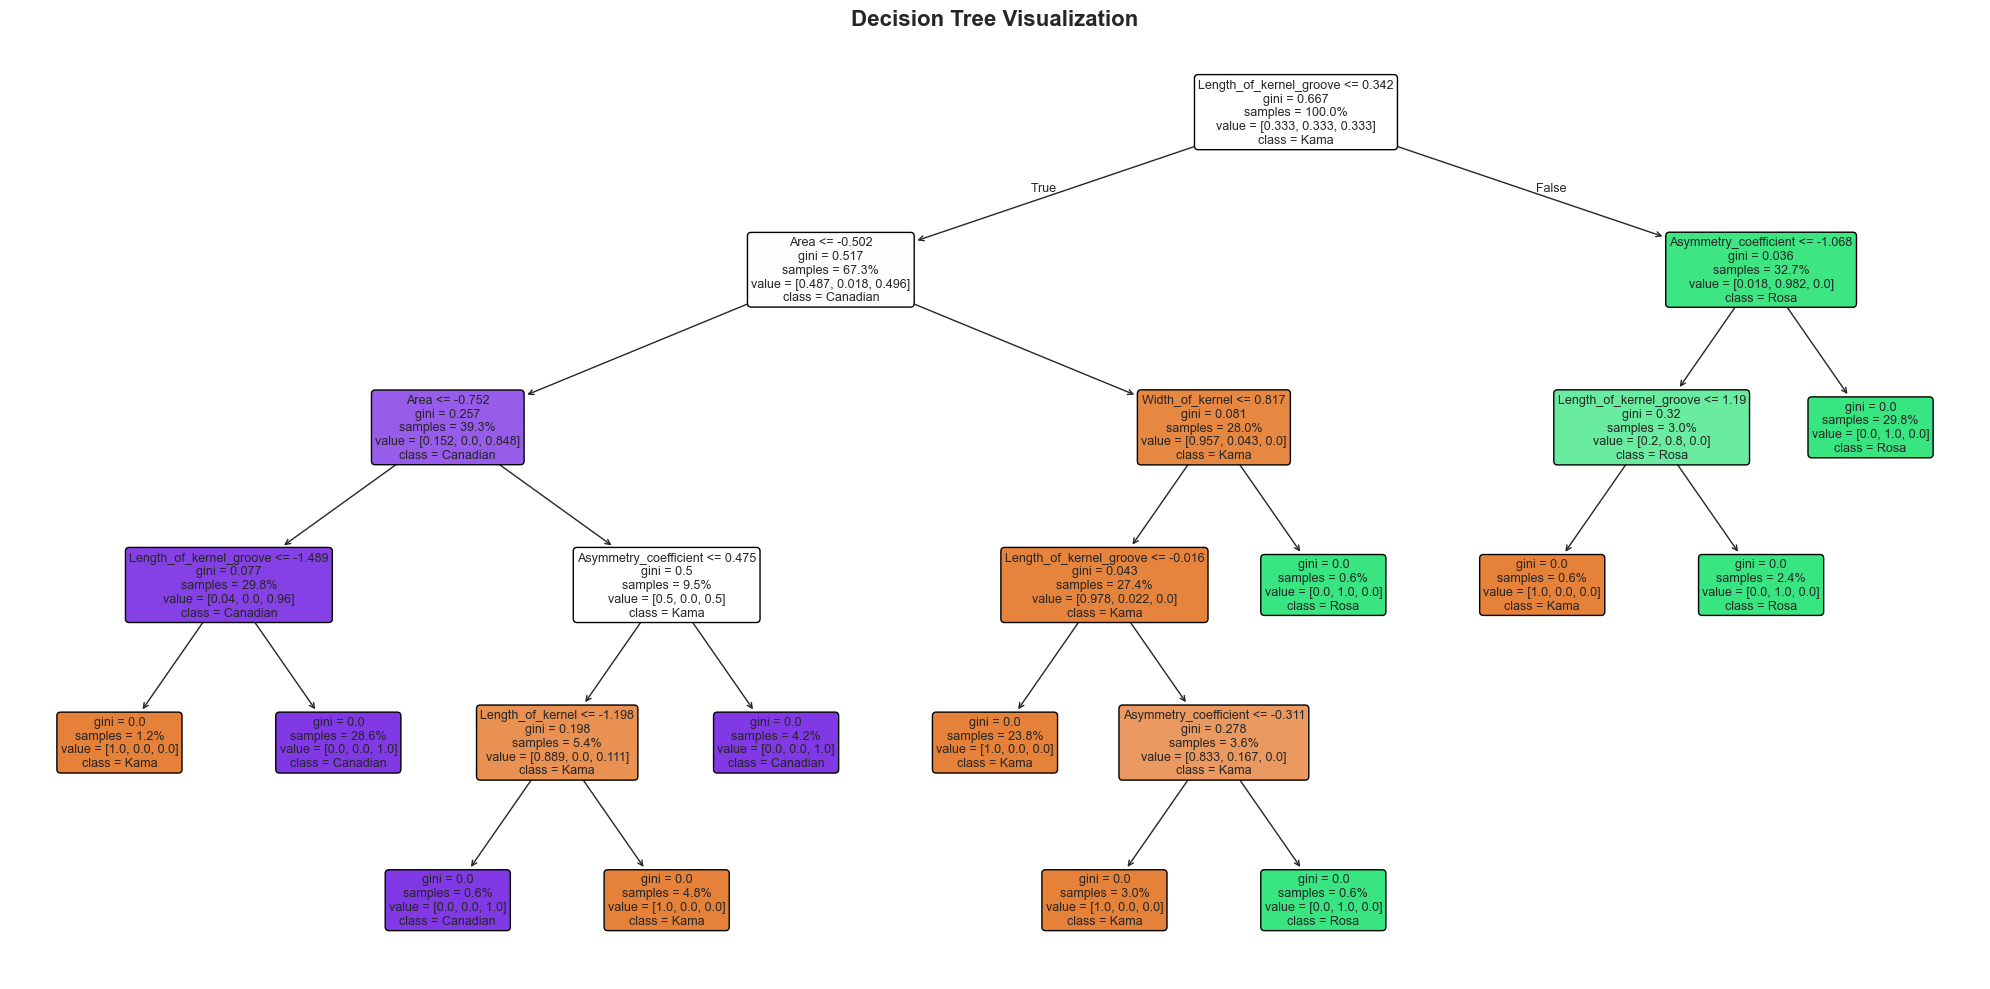

In [10]:
# Visualize the Decision Tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_model, feature_names=list(feature_cols), class_names=class_names,
          filled=True, rounded=True, ax=ax, fontsize=9, proportion=True)
ax.set_title('Decision Tree Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

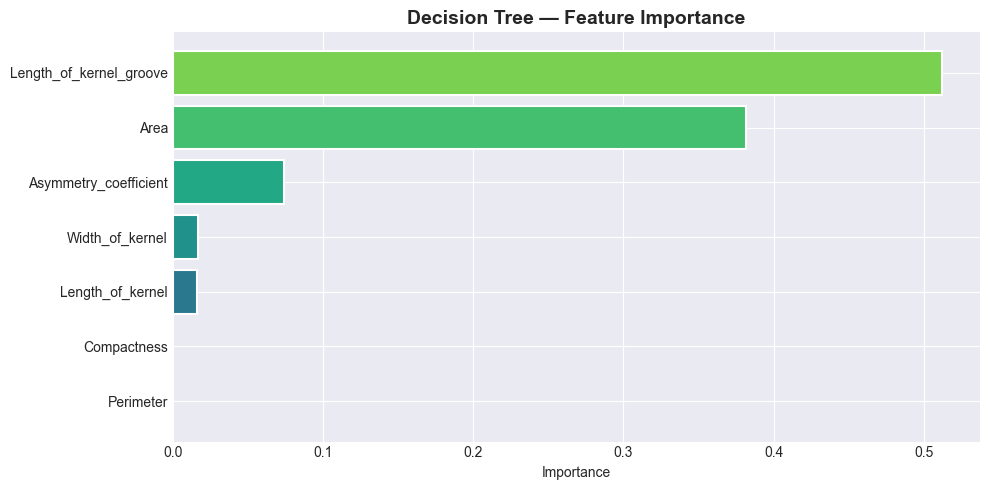

In [11]:
# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color=plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df))),
        edgecolor='white', linewidth=1.5)
ax.set_title('Decision Tree — Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [12]:
# Cross-validation
cv_scores_dt = cross_val_score(dt_model, scaler.transform(X), y, cv=5, scoring='accuracy')
print("Cross-Validation (5-fold):")
print(f"Scores: {cv_scores_dt}")
print(f"Mean Accuracy: {cv_scores_dt.mean():.4f} ± {cv_scores_dt.std():.4f}")

Cross-Validation (5-fold):
Scores: [0.9047619  0.92857143 0.78571429 0.92857143 0.88095238]
Mean Accuracy: 0.8857 ± 0.0530


### 7. Effect of Max Depth on Decision Tree

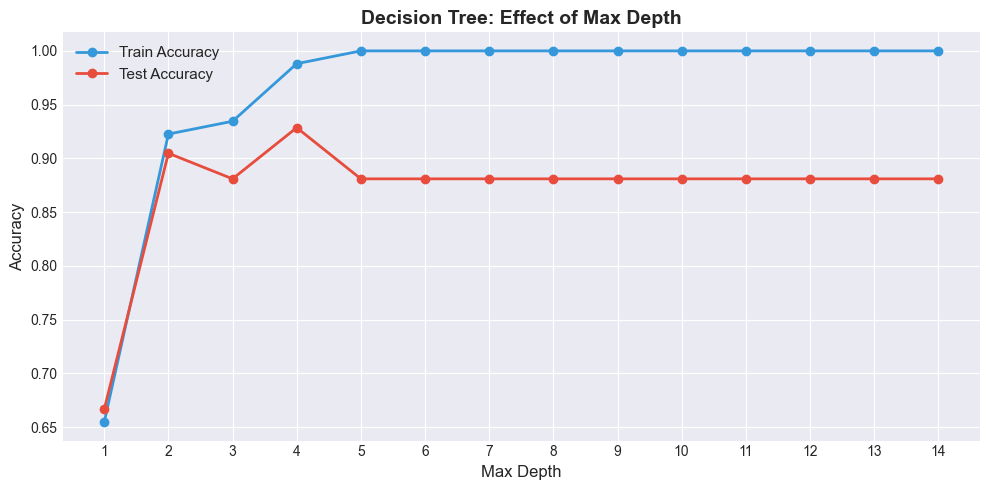

In [13]:
depths = range(1, 15)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_scores.append(dt.score(X_train_scaled, y_train))
    test_scores.append(dt.score(X_test_scaled, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train Accuracy', color='#3498db', linewidth=2)
ax.plot(depths, test_scores, 'o-', label='Test Accuracy', color='#e74c3c', linewidth=2)
ax.set_xlabel('Max Depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision Tree: Effect of Max Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

## 8. Model Comparison

In [14]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'CV Mean Accuracy'],
    'Naïve Bayes': [acc_nb, prec_nb, rec_nb, f1_nb, cv_scores_nb.mean()],
    'Decision Tree': [acc_dt, prec_dt, rec_dt, f1_dt, cv_scores_dt.mean()]
})

print("Model Comparison")
print("=" * 55)
comparison

Model Comparison


,Metric,Naïve Bayes,Decision Tree
0,Accuracy,0.880952,0.880952
1,Precision,0.887064,0.883586
2,Recall,0.880952,0.880952
3,F1 Score,0.877266,0.876628
4,CV Mean Accuracy,0.885714,0.885714


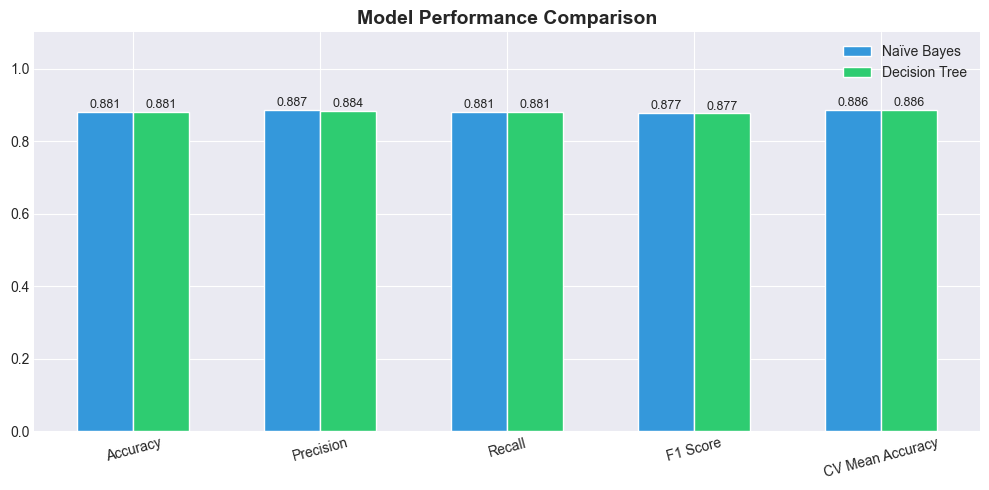

In [15]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.3

bars1 = ax.bar(x - width/2, comparison['Naïve Bayes'], width, label='Naïve Bayes',
               color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['Decision Tree'], width, label='Decision Tree',
               color='#2ecc71', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'], rotation=15)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Conclusion
In this lab, we:
- **Gaussian Naïve Bayes**: Simple probabilistic classifier assuming feature independence. Works well for this dataset.
- **Decision Tree**: Interpretable model with visualization. Feature importance reveals key discriminators.
- Both models perform well on the Seeds dataset due to clear class separation.
- Decision Tree may overfit without depth constraints; cross-validation helps assess generalization.